# HDFC Bank: Fraud Risk Analysis - Part 3

**Objective:** Model Training and Evaluation

In this notebook, we take our model-ready tensors and train two models:
1. A **Logistic Regression Baseline**: A simple linear model to act as a benchmark.
2. A **LightGBM Classifier**: Our primary non-linear gradient boosting model optimized for severe class imbalance.

Since fraud is heavily imbalanced (~3.5%), we will rely on **PR-AUC** (Precision-Recall Area Under Curve) and F1-Scores rather than raw accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

from fraudguard.data.ingestion import load_bank_data, split_temporal
from fraudguard.features.engineering import build_feature_pipeline
from fraudguard.models.training import train_logistic_regression, train_lightgbm
from fraudguard.models.evaluation import evaluate_model

## 1. Data Preparation
Load the data, split temporally, and run the feature engineering pipeline.

In [2]:
# 1. Load Data
data_dir = Path.cwd().parent / "data" / "raw"
df = load_bank_data(data_dir)

# 2. Split Temporally
df_train, df_test = split_temporal(df, test_ratio=0.2)
X_train = df_train.drop(columns=['isFraud'])
y_train = df_train['isFraud'].values
X_test = df_test.drop(columns=['isFraud'])
y_test = df_test['isFraud'].values

# 3. Define Features
numeric_features = ['TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'D1', 'D2', 'D3', 'V1', 'V2', 'V3']
categorical_features = ['ProductCD', 'card4', 'card6', 'P_emaildomain']

# 4. Build and Apply Pipeline
pipeline = build_feature_pipeline(numeric_features, categorical_features)

print("\nProcessing Training Data (fitting Pipeline)...")
X_train_processed = pipeline.fit_transform(X_train)

print("Processing Validation Data (applying Pipeline)...")
X_test_processed = pipeline.transform(X_test)
print(f"Final Matrix Shape: {X_train_processed.shape}")


Processing Training Data (fitting Pipeline)...
Processing Validation Data (applying Pipeline)...
Final Matrix Shape: (472432, 87)


## 2. Baseline Model: Logistic Regression
We train a linear baseline with balanced class weights.

In [3]:
lr_model = train_logistic_regression(X_train_processed, y_train, class_weight='balanced')

# Predict probabilities on the validation set (the future 20% of data)
print("\nEvaluating Logistic Regression on Validation Set:")
lr_probs = lr_model.predict_proba(X_test_processed)[:, 1]
lr_metrics = evaluate_model(y_test, lr_probs, threshold=0.5)

print(f"\nLogistic Regression PR-AUC: {lr_metrics['pr_auc']:.4f}")


Evaluating Logistic Regression on Validation Set:

Logistic Regression PR-AUC: 0.1192


## 3. Advanced Model: LightGBM
We train a Gradient Boosting model which handles non-linear interactions between features (like time-of-day interacting with transaction amount).

In [4]:
# We use scale_pos_weight to tell LightGBM to pay more attention to the rare fraud class
lgb_model = train_lightgbm(
    X_train_processed, y_train,
    X_val=X_test_processed, y_val=y_test
)

print("\nEvaluating LightGBM on Validation Set:")
lgb_probs = lgb_model.predict_proba(X_test_processed)[:, 1]
lgb_metrics = evaluate_model(y_test, lgb_probs, threshold=0.5)

print(f"\nLightGBM PR-AUC: {lgb_metrics['pr_auc']:.4f}")

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032309 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2213
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.845651	valid_0's average_precision: 0.341797	valid_0's binary_logloss: 0.384257
Early stopping, best iteration is:
[1]	valid_0's auc: 0.812131	valid_0's average_precision: 0.283903	valid_0's binary_logloss: 0.141107

Evaluating LightGBM on Validation Set:

LightGBM PR-AUC: 0.2839


## 4. Model Comparison

                      ROC-AUC    PR-AUC  F1-Score
Model                                            
Logistic Regression  0.779037  0.119237  0.161874
LightGBM             0.812131  0.283903  0.000000


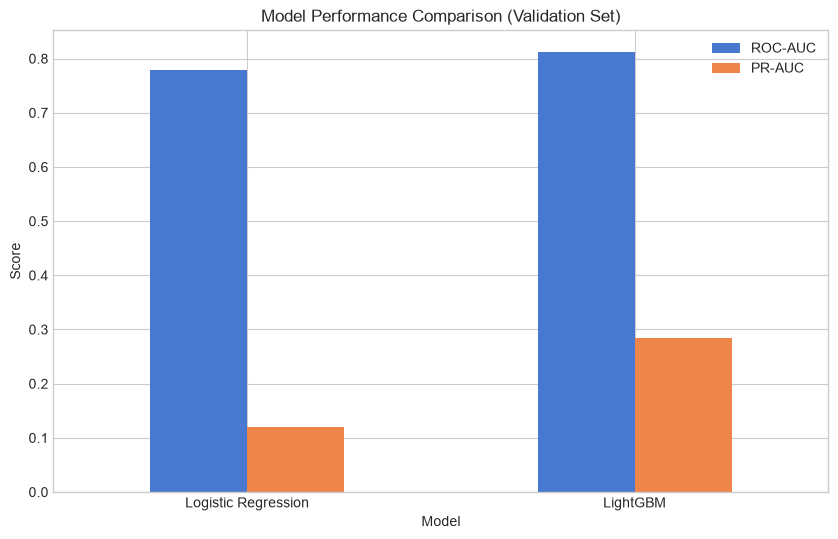

In [5]:
metrics_df = pd.DataFrame([
    {'Model': 'Logistic Regression', 'ROC-AUC': lr_metrics['roc_auc'], 'PR-AUC': lr_metrics['pr_auc'], 'F1-Score': lr_metrics['f1_score']},
    {'Model': 'LightGBM', 'ROC-AUC': lgb_metrics['roc_auc'], 'PR-AUC': lgb_metrics['pr_auc'], 'F1-Score': lgb_metrics['f1_score']}
])

metrics_df.set_index('Model', inplace=True)
print(metrics_df)

metrics_df[['ROC-AUC', 'PR-AUC']].plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Comparison (Validation Set)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()